# Quantum Phase Estimation

Quantum Phase Esitmation is one of the most fundamental algorithms in quantum computing. Its purpose is to estimate the eigenvalue $\phi$ of a given unitary operator $U$ and its eigenstate $\ket{\psi}$, s.t. $U \ket{\psi} = e^{2\pi i \phi} \ket{\psi}$.

In other words, QPE converts the information encoded in the phase of a quantum state into measurable binary data.

QPE is proceeded through the following steps:
1. Initialization:
    Prepare two registers - Ancilla register of m qubits initialized in $\ket{0}^{\otimes m}$, System register $\ket{\psi}$ eigenstate of $U$.

2. Hadamard gates operation:
    Apply Hadamard gate to each ancilla qubit: 
    $$
    \begin{equation}
        (H^{\otimes m} \otimes I)\ket{0}^{\otimes m}\ket{\psi} = \frac{1}{2^{m/2}} \sum_{k=0}^{2^m-1} \ket{k}\ket{\psi}
    \end{equation}
    $$
    This step is prepared for parallel phase encoding, as it creates a uniform superposition over all computational basis states of the ancilla register.

3. Controlled Unitary Operations - Phase kickback:
    For each ancilla qubit, apply a controlled operation $U^{2^k}$:
    $$
    \begin{equation}
        \ket{k}\ket{\psi} \to \ket{k} U^k \ket{\psi}=e^{2\pi i k \phi} \ket{k}\ket{\psi}
    \end{equation}
    $$
    This process is known as phase kickback, the eigenphase $\phi$ of $U$ is transferred into the phase of the ancilla register.
    The resulting state becomes:
    $$
    \begin{equation}
        \frac{1}{2^{m/2}} \sum_{k=0}^{2^m-1}e^{2\pi i k \phi} \ket{k}\ket{\psi}
    \end{equation}
    $$

4. Inverse Quantum Fourier Transformation:
    Apply the inverse QFT to the ancilla register:
    $$
    \begin{equation}
        QFT^{\dagger}\left(\frac{1}{2^{m/2}} \sum_{k=0}^{2^m-1}e^{2\pi i k \phi} \ket{k}\ket{\psi}\right) ~ \approx \ket{\tilde{\phi}}
    \end{equation}
    $$
    where $\ket{\tilde{\phi}}$ encodes the binary digits of the best $m$-bits approximation to $\phi$. This step converts phase information into an amplitude distribution peaked around that binary value.

5. Measurement
    Measure the ancilla register to obtain the binary representation of $\ket{\tilde{\phi}}$, which approximates the true phase $\phi$ with the precision $O(1/2^m)$.

## Define a Hamiltonian for QPE

First, we create a Hamiltonian using Pauli operators. This Hamiltonian represents the quantum system whose eigenvalues we want to estimate using the Quantum Phase Estimation algorithm. The Hamiltonian contains X, Y, and Z Pauli terms acting on two qubits.

In [ ]:
from quri_parts.core import Operator, pauli_label
from quri_algo.problem import QubitHamiltonian

hamiltonian = Operator(
    {
        pauli_label("X0 X1"): 1.0, 
        pauli_label("Y0 Y1"): 2.0,
        pauli_label("Z0 Z1"): 3.0,
    }
)
qubit_hamiltonian = QubitHamiltonian(2, hamiltonian)

## Visualize the QPE Circuit

Here we construct and visualize the Quantum Phase Estimation circuit. We use Trotter time evolution to approximate the unitary operator exp(-iHt), where H is our Hamiltonian and t is the evolution time. The QPE circuit uses m=3 ancilla qubits to estimate the phase with sufficient precision.

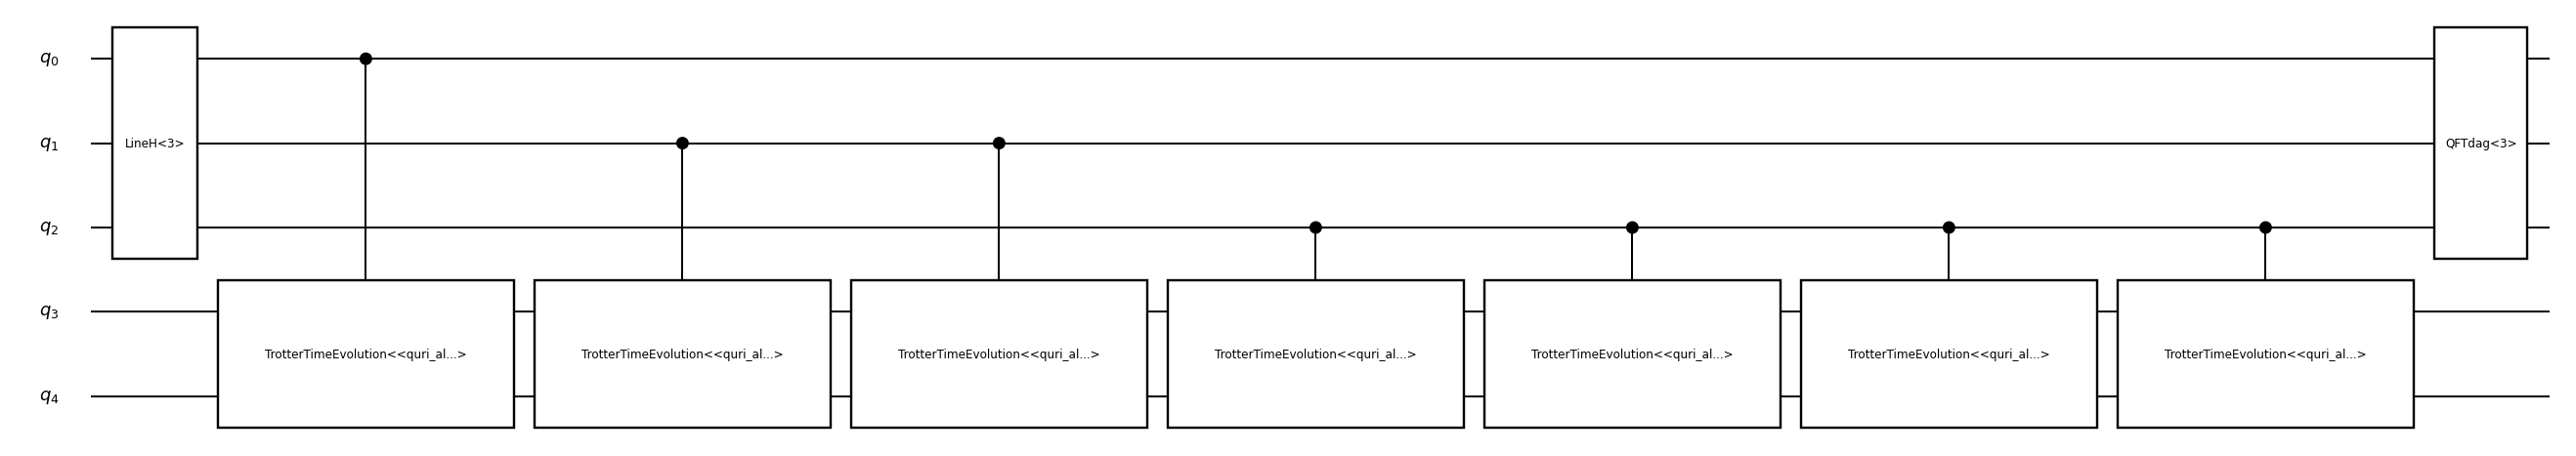

In [ ]:
from quri_parts.qsub.lib import qpe
from quri_parts.qsub.visualize import draw
from quri_algo.qsub.time_evolution.trotter_time_evo import TrotterTimeEvo

t = 1/3
n_trotter = 1
trotter_order = 1

time_evo_op = TrotterTimeEvo(qubit_hamiltonian, t, n_trotter, trotter_order)

m = 3
draw(qpe.QPE(m, time_evo_op ))

## Run the QPE Algorithm

In this section, we execute the Quantum Phase Estimation algorithm to estimate the eigenvalues of our Hamiltonian. We first calculate the exact eigenvalues using classical diagonalization for comparison. Then we prepare an initial quantum state and run QPE with m=9 ancilla qubits for high precision. The algorithm uses 1 million shots to gather sufficient statistics for accurate phase estimation.

Build a state which is a uniform superposition of all the eigenstates of the Hamiltonian

In [ ]:
import numpy as np
from quri_algo.algo.phase_estimation.qpe.qpe import TimeEvolutionQPE
from quri_parts.qsub.primitive import SimulatorBasicSet
from quri_parts.qulacs.sampler import create_qulacs_general_vector_sampler
from quri_parts.core import get_sparse_matrix, quantum_state
from quri_parts.circuit import QuantumCircuit

vals, vecs = np.linalg.eigh(get_sparse_matrix(hamiltonian).toarray())
gs_val = vals[0]

circuit = QuantumCircuit(2)
circuit.add_H_gate(1)
circuit.add_Z_gate(1)
gs_vec = quantum_state(qubit_hamiltonian.n_qubit, circuit=circuit)

sampler = create_qulacs_general_vector_sampler()
n_shots = int(1e6)

m = 10

evolution_time = 1/16
qpe_algo = TimeEvolutionQPE(TrotterTimeEvo, sampler)

qpe_result = qpe_algo.run(gs_vec, n_shots, m, qubit_hamiltonian, evolution_time, primitives=SimulatorBasicSet)

Here we process the QPE results to count how often each eigenvalue was measured. The Counter object aggregates the measurement counts for each estimated eigenvalue, showing the most frequently observed values. This gives us insight into the accuracy and distribution of our phase estimation.

In [ ]:
from collections import Counter
eig_count = Counter({qpe_result.eigen_values[k]: v for k, v in qpe_result.ancilla_register_counts.items()})
eig_count.most_common(4)

[(0.0, np.int64(250812)),
 (2.0, np.int64(250052)),
 (10.0, np.int64(249631)),
 (4.0, np.int64(249505))]

This plot compares the QPE-estimated eigenvalues with the exact eigenvalues calculated classically. The histogram shows the distribution of estimated eigenvalues from QPE measurements, while the red dashed lines indicate the true eigenvalues. This visualization helps assess the accuracy of the quantum phase estimation algorithm.

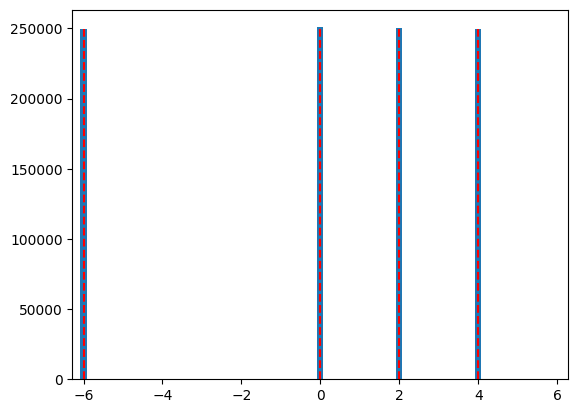

In [ ]:
import matplotlib.pyplot as plt

plt.bar(
    np.angle(np.exp(-2j * np.pi * np.array(list(eig_count.keys())) * evolution_time)) / (-2*np.pi*evolution_time), 
    eig_count.values(),
    width=1/2**m/ evolution_time * 10
)
plt.xlim(-2 * np.pi, 2 * np.pi)
max_height = np.max([c[1] for c in eig_count.most_common(4)])
plt.vlines(vals, 0, max_height, color="red", linestyle="--")
plt.show()

## Circuit Evaluation with NISQ and STAR Devices

Now we'll analyze the QPE circuit performance on different quantum computing architectures using QURI VM. We'll evaluate the circuit on:
1. NISQ (Noisy Intermediate-Scale Quantum) superconducting device
2. STAR (Surface code-based Topologically protected Architecture for fault-tolerant quantum computing) device

This analysis will provide insights into resource requirements, execution time, and fidelity for each architecture.

### NISQ Device Configuration

Configure a NISQ superconducting device with realistic noise parameters including gate errors, timing, and native gate set.

In [ ]:
from quri_parts.backend.devices import nisq_spcond_lattice
from quri_parts.circuit.topology import SquareLattice
from quri_parts.backend.units import TimeValue, TimeUnit
from quri_vm import VM

nisq_1q = 1e-4
nisq_2q = 1e-3
# Generate NISQ device properties
nisq_property = nisq_spcond_lattice.generate_device_property(
    lattice=SquareLattice(5, 5),
    native_gates_1q=("RZ", "SqrtX", "X"),
    native_gates_2q=("CNOT",),
    gate_error_1q=nisq_1q,
    gate_error_2q=nisq_2q,
    gate_error_meas=1e-2,
    gate_time_1q=TimeValue(60, TimeUnit.NANOSECOND),
    gate_time_2q=TimeValue(660, TimeUnit.NANOSECOND),
    gate_time_meas=TimeValue(1.4, TimeUnit.MICROSECOND),
)

# Create NISQ VM
nisq_vm = VM.from_device_prop(nisq_property)

### STAR Device Configuration

Configure a STAR architecture device with surface code error correction. This fault-tolerant architecture provides high fidelity at the cost of increased latency and physical qubit overhead.

In [ ]:
from quri_parts.backend.devices import star_device

# Generate STAR device properties
n_device_logical_qubit = qubit_hamiltonian.n_qubit + m  # QPE requires additional ancilla qubits
p_phys = 1e-4
qec_cycle = TimeValue(1, TimeUnit.MICROSECOND)
code_distance = 9

star_property = star_device.generate_device_property(
    n_device_logical_qubit, code_distance, qec_cycle, p_phys,
)

# Create STAR VM
star_vm = VM.from_device_prop(star_property)

Create TimeEvolutionQPE instances for each VM to enable circuit analysis with different device architectures.

In [ ]:
# Create TimeEvolutionQPE instances for each VM
nisq_qpe_algo = TimeEvolutionQPE(TrotterTimeEvo, nisq_vm.sample)
star_qpe_algo = TimeEvolutionQPE(TrotterTimeEvo, star_vm.sample)

In [ ]:
# Analyze QPE circuits with different VMs using the .analyze method
m = 5
n_shots = int(1e3)

nisq_analysis = nisq_qpe_algo.analyze(
    gs_vec, n_shots, m, nisq_vm.analyze, qubit_hamiltonian, evolution_time
)
star_analysis = star_qpe_algo.analyze(
    gs_vec, n_shots, m, star_vm.analyze, qubit_hamiltonian, evolution_time
)

print("Circuit Analysis Results:")
print(
    f"NISQ - Fidelity: {list(nisq_analysis.circuit_fidelities.values())[0]:.2e}, execution time: {nisq_analysis.total_latency.in_ns() * 1e-9 / 60:.3f} minutes"
)
print(f"STAR - Fidelity: {list(star_analysis.circuit_fidelities.values())[0]:.6f}, STAR execution time: {star_analysis.total_latency.in_ns() * 1e-9 / 60:.3f} minutes")


Circuit Analysis Results:
NISQ - Fidelity: 2.77e-11, execution time: 0.254 minutes
STAR - Fidelity: 0.943867, STAR execution time: 1.657 minutes


### Gate Count Analysis

Count specific gate types for NISQ (CNOT gates) and STAR (RZ gates) devices using qsub GateCountEvaluatorHooks.

In [ ]:
from quri_parts.qsub.evaluate import Evaluator
from quri_parts.qsub.eval import GateCountEvaluatorHooks
from quri_parts.qsub.lib import std
from quri_algo.algo.phase_estimation.qpe.qpe import get_qpe_msub
from quri_parts.qsub.primitive import AllBasicSet

# Create compiled subroutine for gate counting
qpe_msub = get_qpe_msub(
    ancilla_count=m,
    hamiltonian=qubit_hamiltonian,
    time_evo_op_factory=TrotterTimeEvo,
    scale_factor=evolution_time,
    primitives=AllBasicSet
)

# Count all gates
gate_counter = Evaluator(GateCountEvaluatorHooks())
gate_counts = gate_counter.run(qpe_msub)

print(({o[1]: v for o, v in gate_counts.items()}))

# Extract gate counts
cnot_count = gate_counts.get(std.CNOT.base_id, 0)
toffoli_count = gate_counts.get(std.Toffoli.base_id, 0)
swap_count = gate_counts.get(std.SWAP.base_id, 0)
cz_count = gate_counts.get(std.CZ.base_id, 0)
rz_count = gate_counts.get(std.RZ.base_id, 0)
ry_count = gate_counts.get(std.RY.base_id, 0)
phase_count = gate_counts.get(std.Phase.base_id, 0)

# Estimate CNOT count for NISQ
# Toffoli = 6 CNOTs, SWAP = 3 CNOTs, CZ = 1 CNOT
nisq_cnot_estimate = cnot_count + (toffoli_count * 6) + (swap_count * 3) + cz_count

# Estimate RZ count for STAR
# RY, Phase = 1 RZ each, Toffoli = 7 RZs
star_rz_estimate = rz_count + ry_count + phase_count + (toffoli_count * 7)

p_phys_star = p_phys
nisq_cnot_error = nisq_2q

print("Gate Count Analysis:")
print(f" CNOT: {cnot_count}, Toffoli: {toffoli_count}, SWAP: {swap_count}, CZ: {cz_count}, RZ: {rz_count}, RY: {ry_count}, Phase: {phase_count}")
print(f"NISQ CNOT estimate: {nisq_cnot_estimate}, NISQ CNOT fidelity = {(1 - nisq_cnot_error)**nisq_cnot_estimate}")
print(f"STAR RZ estimate: {star_rz_estimate}, STAR gate fidelity: {((1 - 2*p_phys_star / 15)**2)**star_rz_estimate}")

{'H': 258, 'RY': 248, 'CZ': 124, 'Toffoli': 186, 'CNOT': 454, 'RZ': 454, 'SWAP': 2, 'Phase': 10}
Gate Count Analysis:
 CNOT: 454, Toffoli: 186, SWAP: 2, CZ: 124, RZ: 454, RY: 248, Phase: 10
NISQ CNOT estimate: 1700, NISQ CNOT fidelity = 0.18252820552270244
STAR RZ estimate: 2014, STAR gate fidelity: 0.9477097213591666


1. STAR fidelity is larger than the above estimated one because we do not take background fidelity into account here
2. NISQ fidelity is larger here because we do not take the device connectivity into account in this rought estimation.